In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = "/Users/tempdelta/Desktop/ua_pl/data"
output_plots_dir = "/Users/tempdelta/Desktop/ua_pl/plots"
os.makedirs(output_plots_dir, exist_ok=True)

def extract_clean_headers(df_raw, start_row_idx, date_col_idx):
    headers = []
    header_rows = df_raw.iloc[:start_row_idx, :]
    
    for col in range(df_raw.shape[1]):
        if col == date_col_idx:
            headers.append("Period")
            continue
            
        header_parts = []
        for r in range(start_row_idx):
            val = str(header_rows.iloc[r, col]).strip()
            if val and val != "nan" and not val.isdigit():
                if "balance sheet" not in val.lower() and "narodowy bank" not in val.lower():
                    header_parts.append(val)
                    
        full_name = " ".join(header_parts).strip()
        full_name = " ".join(full_name.split())
        
        if not full_name or full_name.isdigit() or "unnamed" in full_name.lower():
            full_name = f"Column_{col}"
            
        headers.append(full_name)
    return headers

def clean_and_plot_sheet(excel_path, sheet_name, file_name_attr):
    try:
        df_raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None)
        
        if df_raw.empty or df_raw.shape[0] < 5:
            return

        date_col_idx = None
        start_row_idx = None
        
        for col in range(df_raw.shape[1]):
            converted_dates = pd.to_datetime(df_raw.iloc[:, col], errors='coerce')
            if converted_dates.notna().sum() > 5:
                date_col_idx = col
                start_row_idx = converted_dates.notna().idxmax()
                break
                
        if date_col_idx is None:
            return

        dates = pd.to_datetime(df_raw.iloc[start_row_idx:, date_col_idx], errors='coerce')
        headers = extract_clean_headers(df_raw, start_row_idx, date_col_idx)
        
        numeric_cols = {}
        for col in range(df_raw.shape[1]):
            if col == date_col_idx:
                continue
            series = pd.to_numeric(df_raw.iloc[start_row_idx:, col], errors='coerce')
            if series.notna().sum() > 5:
                col_name = headers[col]
                numeric_cols[col_name] = series

        if not numeric_cols:
            return

        df_clean = pd.DataFrame(numeric_cols)
        df_clean.index = dates
        df_clean = df_clean.loc[df_clean.index.notna()]
        df_clean = df_clean.sort_index()

        plt.figure(figsize=(14, 8))
        for col_name in df_clean.columns:
            plt.plot(df_clean.index, df_clean[col_name], label=col_name, alpha=0.8, linewidth=1.5)
            
        plt.title(f"File: {file_name_attr} | Sheet: {sheet_name}", fontsize=12, pad=15, fontweight='bold')
        plt.xlabel("Year", fontsize=10)
        plt.ylabel("Value", fontsize=10)
        plt.grid(True, linestyle="--", alpha=0.5)
        
        if len(df_clean.columns) <= 8:
            plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
        else:
            plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=7, ncol=2)
            
        plt.tight_layout()
        
        safe_file_name = "".join([c if c.isalnum() or c in ("-", "_") else "_" for c in file_name_attr])
        safe_sheet_name = "".join([c if c.isalnum() or c in ("-", "_") else "_" for c in sheet_name])
        
        output_path = os.path.join(output_plots_dir, f"{safe_file_name}__{safe_sheet_name}.png")
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"    -> Saved plot to plots/: {safe_file_name}__{safe_sheet_name}.png")
        
    except Exception as e:
        print(f"    -> Error processing sheet {sheet_name}: {e}")

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(('.xlsx', '.xls')) and not file.startswith('~$'):
            excel_path = os.path.join(root, file)
            file_name_attr = os.path.splitext(file)[0]
            
            print(f"\nProcessing file: {file}")
            try:
                xl = pd.ExcelFile(excel_path)
                for sheet in xl.sheet_names:
                    clean_and_plot_sheet(excel_path, sheet, file_name_attr)
            except Exception as e:
                print(f"Failed to read file {file}: {e}")

print(f"\nAll plots saved to: {output_plots_dir}")


Processing file: bilans_nbp_en.xlsx


/var/folders/c7/kt215xrj6118ksq6w0c3ffqm0000gn/T/ipykernel_9580/3506276194.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted_dates = pd.to_datetime(df_raw.iloc[:, col], errors='coerce')
/var/folders/c7/kt215xrj6118ksq6w0c3ffqm0000gn/T/ipykernel_9580/3506276194.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted_dates = pd.to_datetime(df_raw.iloc[:, col], errors='coerce')


    -> Saved plot to plots/: bilans_nbp_en__NBP_A.png


/var/folders/c7/kt215xrj6118ksq6w0c3ffqm0000gn/T/ipykernel_9580/3506276194.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted_dates = pd.to_datetime(df_raw.iloc[:, col], errors='coerce')


    -> Saved plot to plots/: bilans_nbp_en__NBP_P.png

Processing file: wsta.xlsx


...

    -> Saved plot to plots/: podaz_bilansowa_en__AM_12MP.png


/var/folders/c7/kt215xrj6118ksq6w0c3ffqm0000gn/T/ipykernel_9580/3506276194.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted_dates = pd.to_datetime(df_raw.iloc[:, col], errors='coerce')


    -> Saved plot to plots/: podaz_bilansowa_en__CK_12MP.png

Processing file: miarypieniadza_nowe_en.xlsx


/var/folders/c7/kt215xrj6118ksq6w0c3ffqm0000gn/T/ipykernel_9580/3506276194.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted_dates = pd.to_datetime(df_raw.iloc[:, col], errors='coerce')


    -> Saved plot to plots/: miarypieniadza_nowe_en__Arkusz1.png

All plots saved to: /Users/tempdelta/Desktop/ua_pl/plots


In [12]:
df = pd.read_csv("data/gminy_pit_revenues.csv")
df.head()

,gmina_id,gmina_name,year,pit_value
0,11212001011,Bochnia,1995,2019895.0
1,11212001011,Bochnia,1996,2502707.0
2,11212001011,Bochnia,1997,3483085.0
3,11212001011,Bochnia,1998,4984094.0
4,11212001011,Bochnia,1999,6487314.0


In [13]:
import os
import requests
import pandas as pd

df = pd.read_csv("data/gminy_pit_revenues.csv")

df["gmina_id_str"] = df["gmina_id"].astype(str).str.zfill(12)
df["powiat_id"] = df["gmina_id_str"].str[:10]

powiat_names = {}
page = 0

while True:
    url = "https://bdl.stat.gov.pl/api/v1/Units"
    params = {"level": 5, "page-size": 100, "page": page}
    response = requests.get(url, params=params)
    if response.status_code != 200:
        break
    data = response.json()
    results = data.get("results", [])
    if not results:
        break
    for unit in results:
        powiat_names[unit.get("id")[:10]] = unit.get("name")
    page += 1

powiat_df = df.groupby(["powiat_id", "year"])["pit_value"].sum().reset_index()
powiat_df["powiat_name"] = powiat_df["powiat_id"].map(powiat_names)

powiat_df = powiat_df[["powiat_id", "powiat_name", "year", "pit_value"]]

os.makedirs("data", exist_ok=True)
powiat_df.to_csv("data/powiaty_pit_revenues.csv", index=False)

print(powiat_df.head(15))

     powiat_id       powiat_name  year   pit_value
0   0112120010  Powiat bocheński  1995   6918153.0
1   0112120010  Powiat bocheński  1996   8187551.0
2   0112120010  Powiat bocheński  1997  10378843.0
3   0112120010  Powiat bocheński  1998  13403205.0
4   0112120010  Powiat bocheński  1999  15221103.0
5   0112120010  Powiat bocheński  2000  15100051.0
6   0112120010  Powiat bocheński  2001  12387207.0
7   0112120010  Powiat bocheński  2002  12904577.0
8   0112120010  Powiat bocheński  2003  13134375.0
9   0112120010  Powiat bocheński  2004  19112468.0
10  0112120010  Powiat bocheński  2005  22420755.0
11  0112120010  Powiat bocheński  2006  24619868.0
12  0112120010  Powiat bocheński  2007  30738391.0
13  0112120010  Powiat bocheński  2008  37946448.0
14  0112120010  Powiat bocheński  2009  34121101.0


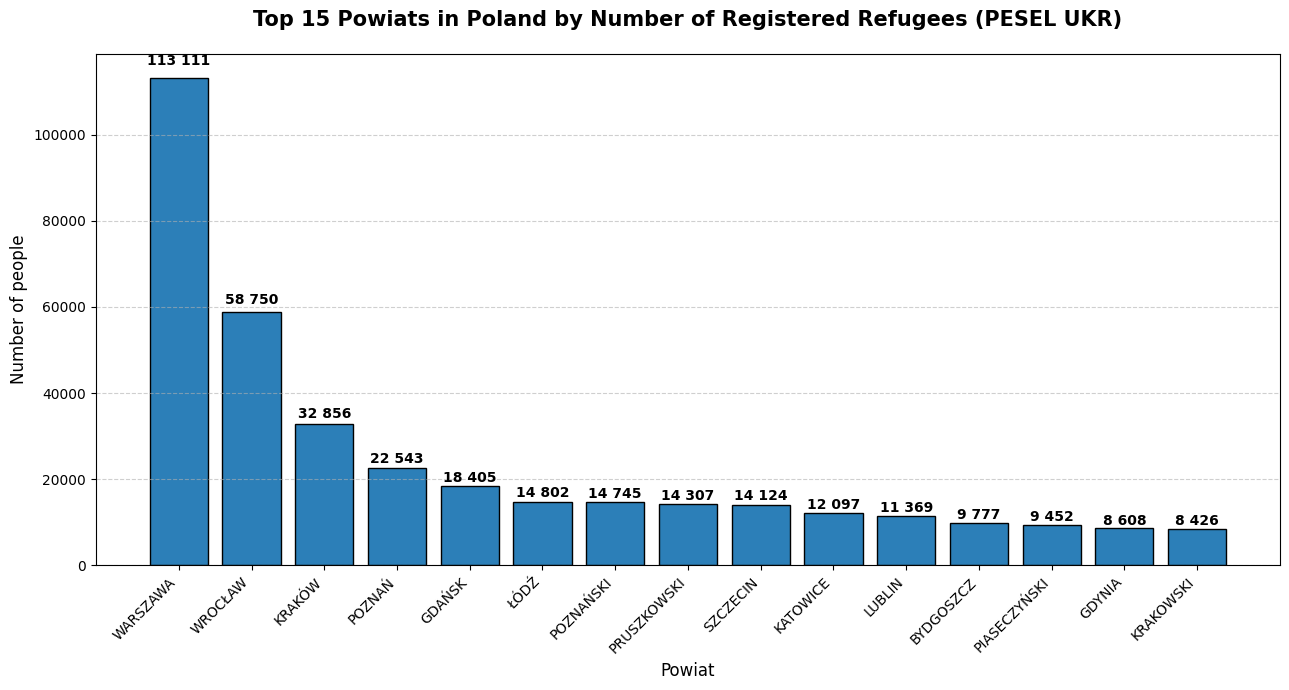

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "pesel_ukr_data/pesel_ukr_powiaty_latest.xlsx"
df_pesel = pd.read_excel(file_path)

df_clean = df_pesel.iloc[2:, [1, 5]].copy()

df_clean.columns = ["Powiat", "Liczba"]

df_clean = df_clean.dropna(subset=["Powiat", "Liczba"])

df_clean["Liczba"] = df_clean["Liczba"].astype(str).str.replace("<", "").astype(float)

top_15_powiaty = df_clean.nlargest(15, "Liczba")

plt.figure(figsize=(13, 7))
bars = plt.bar(top_15_powiaty["Powiat"], top_15_powiaty["Liczba"], color='#2c7fb8', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f"{int(yval):,}".replace(",", " "), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Top 15 Powiats in Poland by Number of Registered Refugees (PESEL UKR)", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Powiat", fontsize=12)
plt.ylabel("Number of people", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("pesel_ukr_data/top15_pesel_ukr_cleaned.png", dpi=150)
plt.show()

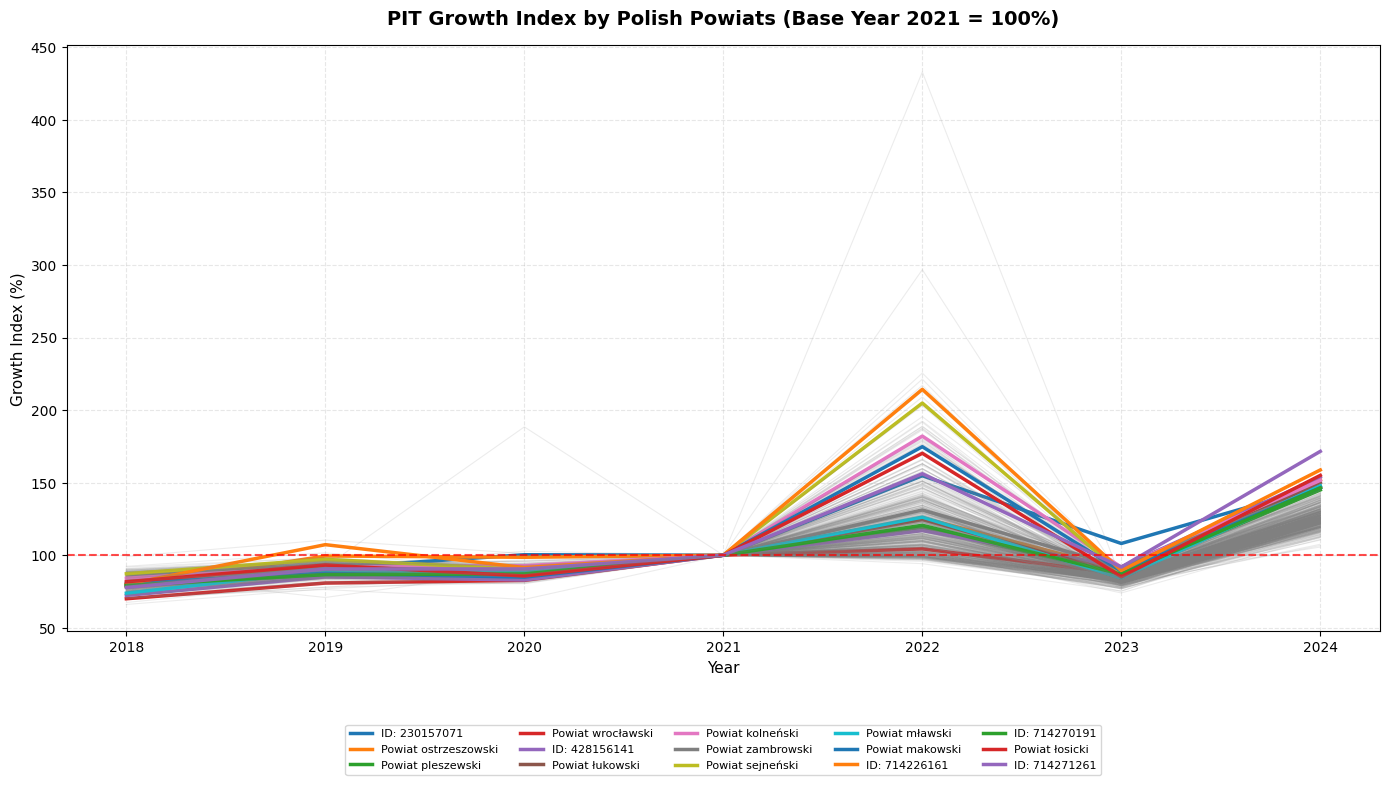

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/Users/tempdelta/Desktop/ua_pl/data/powiaty_pit_revenues.csv"
output_dir = "/Users/tempdelta/Desktop/ua_pl/plots"
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(file_path)
df = df[df["year"] >= 2018]

df_2021 = df[df["year"] == 2021][["powiat_id", "pit_value"]].rename(columns={"pit_value": "pit_2021"})
df = df.merge(df_2021, on="powiat_id")
df["pit_index"] = (df["pit_value"] / df["pit_2021"]) * 100

latest_year = df["year"].max()
top_growth = df[df["year"] == latest_year].nlargest(15, "pit_index")["powiat_id"].tolist()

plt.figure(figsize=(14, 8))

for p_id in df["powiat_id"].unique():
    p_data = df[df["powiat_id"] == p_id].sort_values("year")
    if p_data.empty:
        continue
    p_name = p_data["powiat_name"].iloc[0] if pd.notna(p_data["powiat_name"].iloc[0]) else f"ID: {p_id}"
    
    if p_id in top_growth:
        plt.plot(p_data["year"], p_data["pit_index"], linewidth=2.5, label=p_name)
    else:
        plt.plot(p_data["year"], p_data["pit_index"], alpha=0.15, linewidth=0.8, color="gray")

plt.axhline(100, color="red", linestyle="--", alpha=0.7)
plt.title("PIT Growth Index by Polish Powiats (Base Year 2021 = 100%)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Growth Index (%)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=8, ncol=5, frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "powiaty_growth_index.png"), dpi=150, bbox_inches="tight")
plt.show()

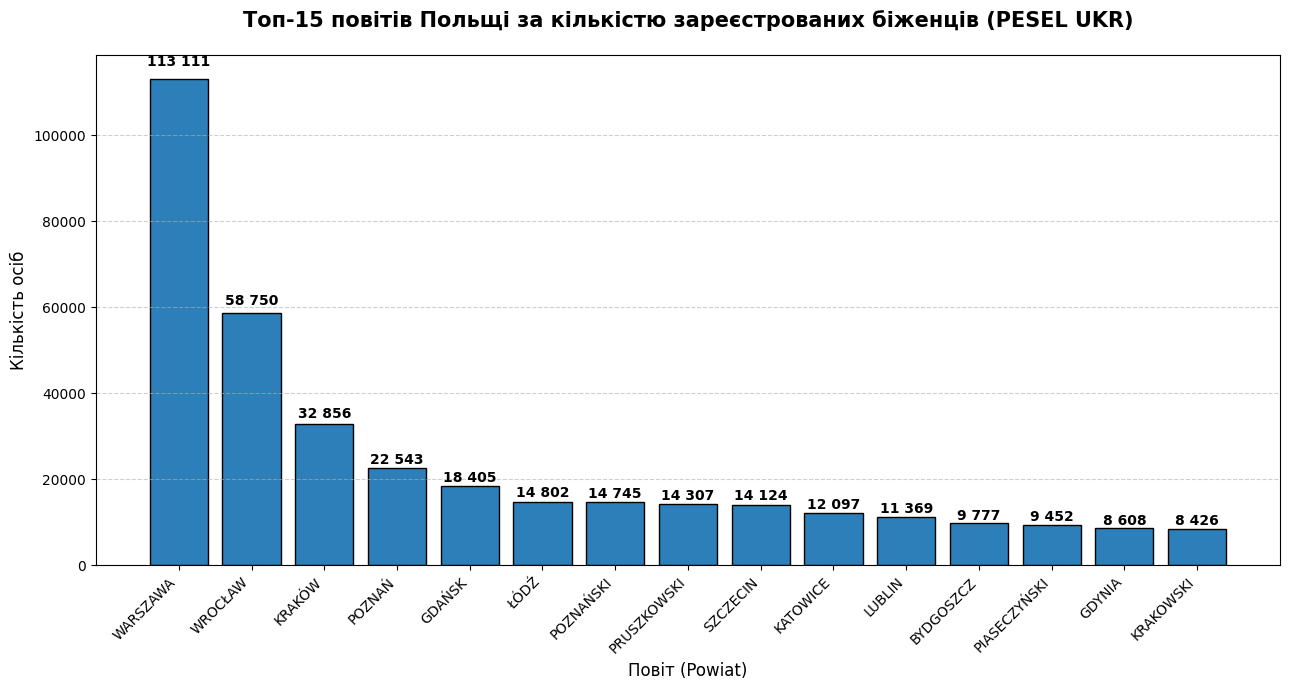

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "pesel_ukr_data/pesel_ukr_powiaty_latest.xlsx"
df_pesel = pd.read_excel(file_path)

# 1. Відрізаємо перші 2 технічні рядки (де лежать слова KOBIET, 2026 і тд) 
# та беремо лише колонку 1 (назви) і колонку 5 (загальна сума)
df_clean = df_pesel.iloc[2:, [1, 5]].copy()

# 2. Даємо нормальні людські назви
df_clean.columns = ["Powiat", "Liczba"]

# 3. Очищаємо від сміття (прибираємо порожні рядки)
df_clean = df_clean.dropna(subset=["Powiat", "Liczba"])

# 4. Перетворюємо числа з тексту у формат integer (цілі числа)
# Про всяк випадок прибираємо знаки "<", які іноді ставлять держоргани для малих значень (наприклад "<2")
df_clean["Liczba"] = df_clean["Liczba"].astype(str).str.replace("<", "").astype(float)

# 5. Беремо Топ-15 повітів
top_15_powiaty = df_clean.nlargest(15, "Liczba")

# --- МАЛЮЄМО ГРАФІК ---
plt.figure(figsize=(13, 7))
bars = plt.bar(top_15_powiaty["Powiat"], top_15_powiaty["Liczba"], color='#2c7fb8', edgecolor='black')

# Додаємо цифри над кожним стовпчиком
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f"{int(yval):,}".replace(",", " "), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Топ-15 повітів Польщі за кількістю зареєстрованих біженців (PESEL UKR)", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Повіт (Powiat)", fontsize=12)
plt.ylabel("Кількість осіб", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("pesel_ukr_data/top15_pesel_ukr_cleaned.png", dpi=150)
plt.show()

   Year_Group    Count
0        2026   1275.0
1        2025   5464.0
2        2024   6488.0
3        2023   7751.0
4        2022   9805.0
5        2021  18745.0
6        2020  20131.0
7        2019  19562.0
8        2018  19760.0
9        2017  21019.0
10       2016  22369.0
11       2015  22958.0
12       2014  24736.0
13       2013  24598.0
14       2012  25116.0
15       2011  23535.0
16       2010  23759.0
17       2009  25681.0
18       2008  31706.0
19       2007  38395.0
20       2006  37488.0
21       2005  31685.0
22       2004  29143.0
23  1999-2003  70647.0
24  1994-1998  54740.0
25  1989-1993  63826.0
26  1984-1988  73170.0
27  1979-1983  60769.0
28  1974-1978  43034.0
29  1969-1973  30318.0
30  1964-1968  22149.0
31  1959-1963  22508.0
32   ...-1958  37794.0


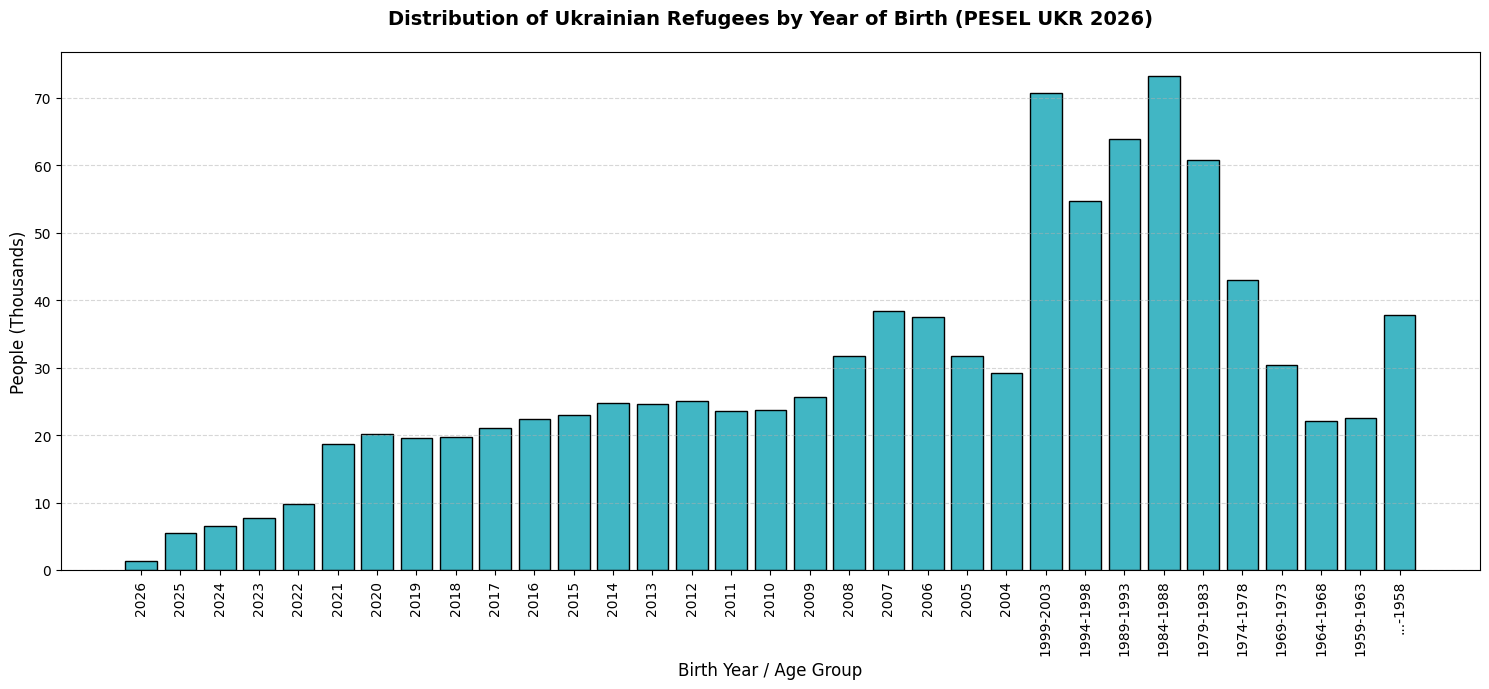

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "pesel_ukr_data/pesel_ukr_powiaty_latest.xlsx"
df = pd.read_excel(file_path, header=None)

year_row = df.iloc[2]
data_rows = df.iloc[3:]

age_distribution = {}

for col_idx in range(3, df.shape[1]):
    label = str(year_row.iloc[col_idx]).strip()
    if label and label != "nan" and label != "WSZYSTKICH":
        col_values = pd.to_numeric(data_rows.iloc[:, col_idx], errors='coerce').fillna(0)
        total_sum = col_values.sum()
        if total_sum > 0:
            age_distribution[label] = age_distribution.get(label, 0) + total_sum

age_df = pd.DataFrame(list(age_distribution.items()), columns=["Year_Group", "Count"])

print(age_df)

plt.figure(figsize=(15, 7))
plt.bar(age_df["Year_Group"], age_df["Count"] / 1000, color="#41b6c4", edgecolor="black")
plt.title("Distribution of Ukrainian Refugees by Year of Birth (PESEL UKR 2026)", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Birth Year / Age Group", fontsize=12)
plt.ylabel("People (Thousands)", fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("pesel_ukr_data/refugee_age_distribution.png", dpi=150)
plt.show()

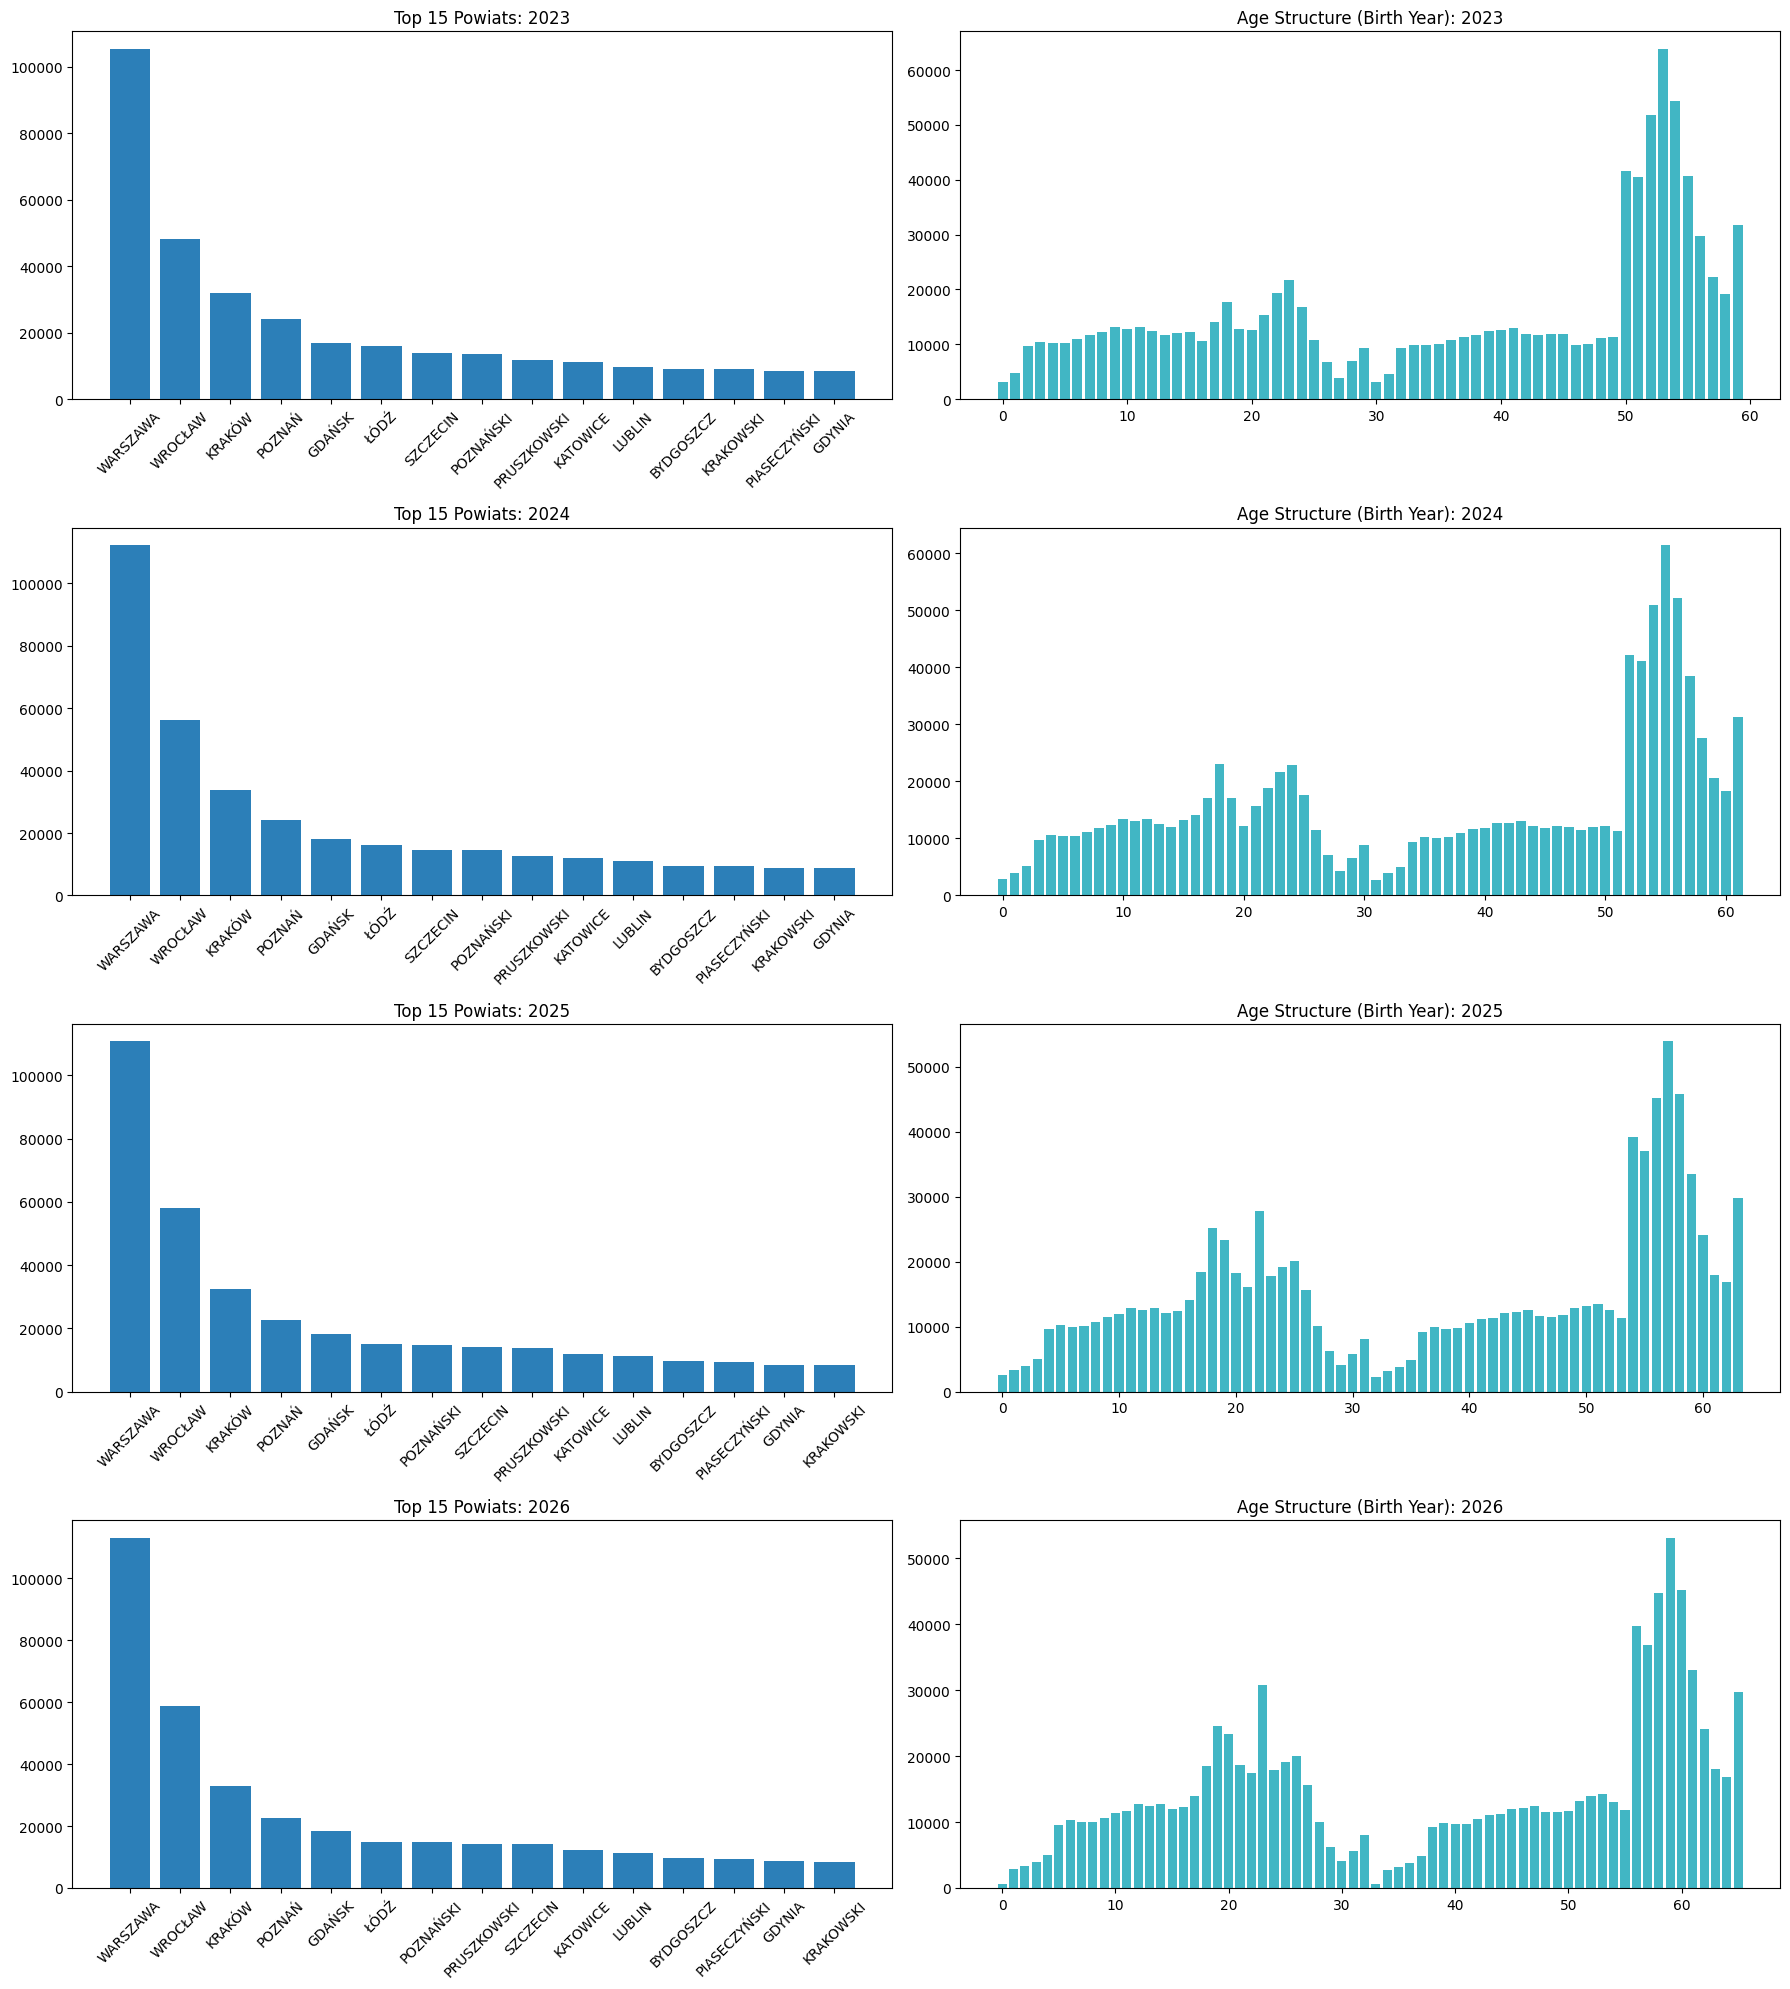

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

folder_path = "pesel_ukr_data/annual_slices"
files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))
years = [f.split('_')[-1].replace('.xlsx', '') for f in files]

fig, axes = plt.subplots(len(files), 2, figsize=(18, 5 * len(files)))

for i, file in enumerate(files):
    year = years[i]
    df = pd.read_excel(file, header=None)
    
    df_powiat = df.iloc[3:, [1, 5]].copy()
    df_powiat.columns = ["Powiat", "Total"]
    df_powiat["Total"] = pd.to_numeric(df_powiat["Total"], errors='coerce').fillna(0)
    top_15 = df_powiat.nlargest(15, "Total")
    
    age_data = df.iloc[3:, 6:].apply(pd.to_numeric, errors='coerce').fillna(0)
    age_totals = age_data.sum(axis=0)
    
    axes[i, 0].bar(top_15["Powiat"], top_15["Total"], color='#2c7fb8')
    axes[i, 0].set_title(f"Top 15 Powiats: {year}")
    axes[i, 0].tick_params(axis='x', rotation=45)
    
    axes[i, 1].bar(range(len(age_totals)), age_totals, color='#41b6c4')
    axes[i, 1].set_title(f"Age Structure (Birth Year): {year}")

plt.tight_layout()
plt.savefig("pesel_ukr_data/combined_yearly_analysis.png", dpi=150)
plt.show()

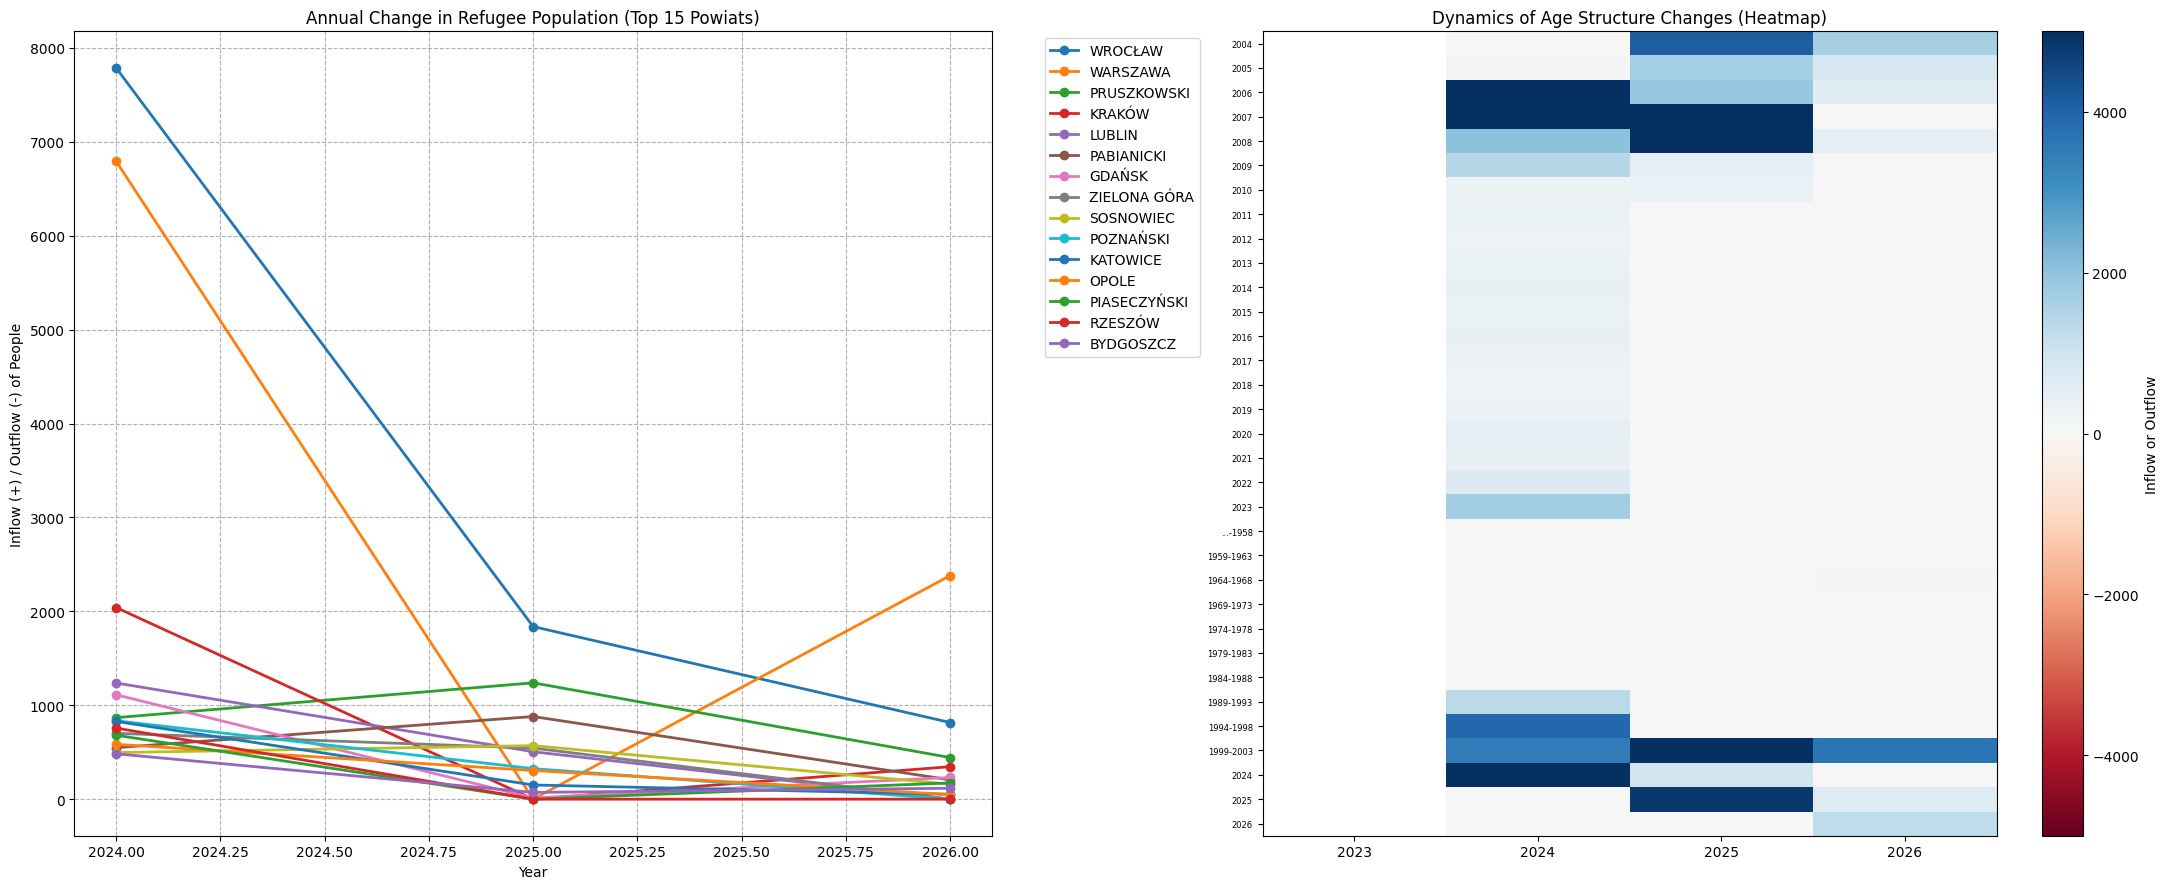

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import re

folder_path = "pesel_ukr_data/annual_slices"
files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

all_powiats = []
all_ages = []

for file in files:
    match = re.search(r'\d{4}', os.path.basename(file))
    year = int(match.group(0)) if match else 0
    df = pd.read_excel(file, header=None)
    
    powiat_df = df.iloc[3:, [1, 5]].copy()
    powiat_df.columns = ["Powiat", "Total"]
    powiat_df["Year"] = year
    all_powiats.append(powiat_df)
    
    age_labels = df.iloc[2, 6:].values
    age_values = df.iloc[3:, 6:].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=0)
    age_series = pd.Series(age_values.values, index=age_labels)
    age_series = age_series.groupby(level=0).sum()
    age_series.name = year
    all_ages.append(age_series)

df_master = pd.concat(all_powiats)
df_master["Total"] = pd.to_numeric(df_master["Total"], errors='coerce').fillna(0)

pivot_powiat = df_master.pivot_table(index="Powiat", columns="Year", values="Total", aggfunc='sum')
delta_powiat = pivot_powiat.diff(axis=1).clip(lower=0)

age_matrix = pd.concat(all_ages, axis=1).fillna(0)
delta_age = age_matrix.diff(axis=1).clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

top_15 = delta_powiat.abs().sum(axis=1).nlargest(15).index
delta_powiat.loc[top_15].T.plot(kind='line', marker='o', ax=axes[0], linewidth=2)
axes[0].set_title("Annual Change in Refugee Population (Top 15 Powiats)")
axes[0].set_ylabel("Inflow (+) / Outflow (-) of People")
axes[0].grid(True, linestyle='--')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

im = axes[1].imshow(delta_age, cmap='RdBu', aspect='auto', vmin=-5000, vmax=5000)
axes[1].set_title("Dynamics of Age Structure Changes (Heatmap)")
axes[1].set_xticks(range(len(delta_age.columns)))
axes[1].set_xticklabels(delta_age.columns)
axes[1].set_yticks(range(len(delta_age.index)))
axes[1].set_yticklabels(delta_age.index, fontsize=6)
plt.colorbar(im, ax=axes[1], label="Inflow or Outflow")

plt.tight_layout()
plt.show()

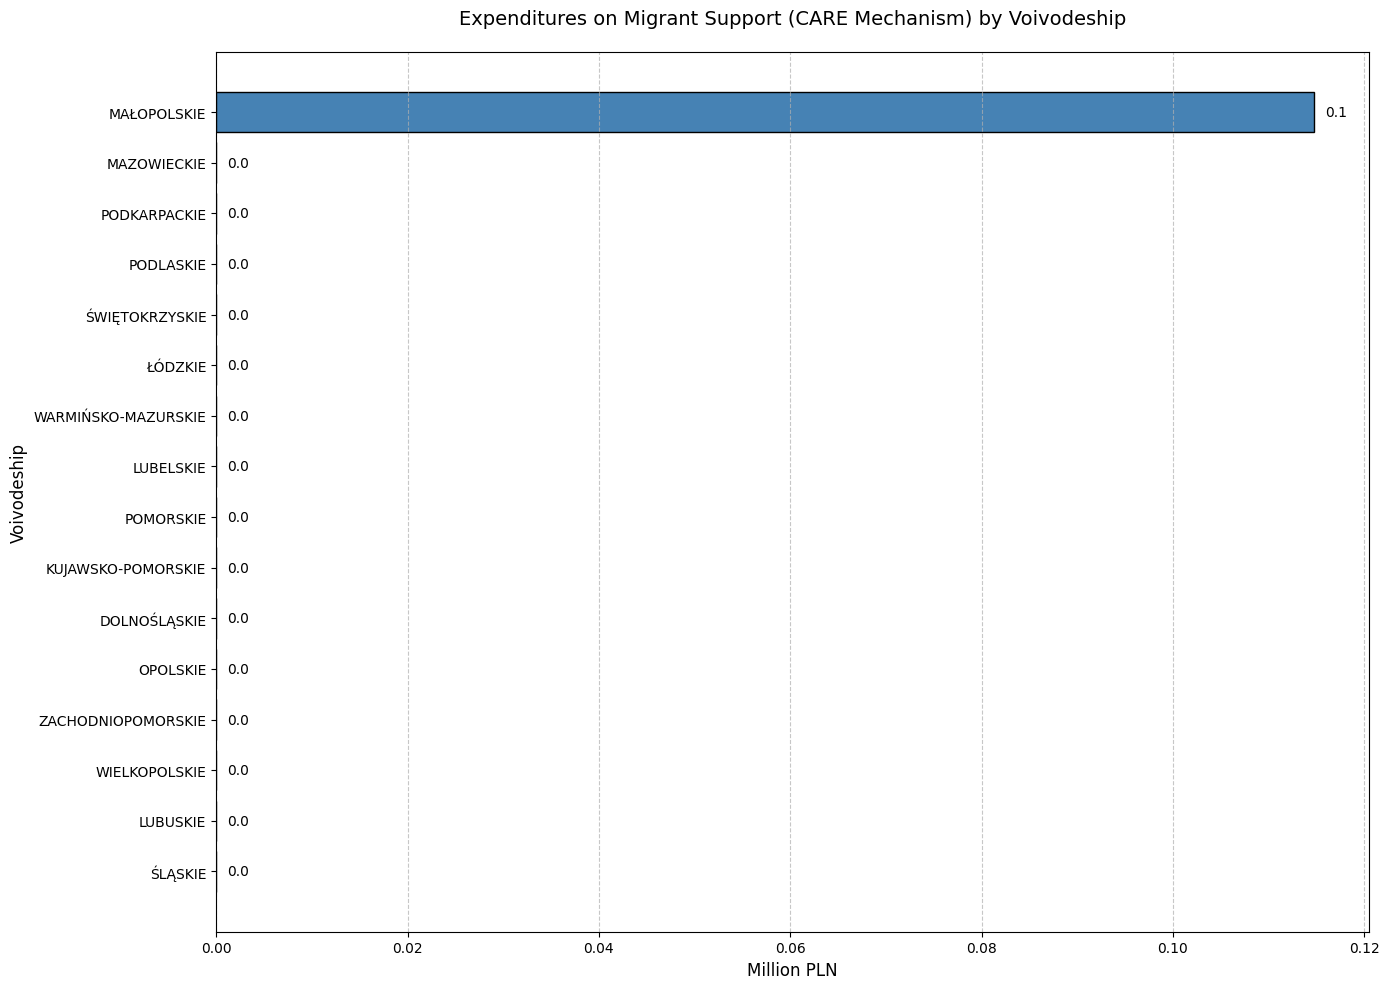

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

file_path = "/Users/tempdelta/Desktop/ua_pl/expenses_data/wojewodztwa_expenses_care.csv"

if not os.path.exists(file_path):
    print("Error: File not found.")
else:
    df = pd.read_csv(file_path)
    
    df['expense_value_mln'] = pd.to_numeric(df['expense_value'], errors='coerce').fillna(0) / 1000000
    
    df_sorted = df.sort_values('expense_value_mln', ascending=True)

    plt.figure(figsize=(14, 10))
    bars = plt.barh(df_sorted['wojewodztwo_name'], df_sorted['expense_value_mln'], color='steelblue', edgecolor='black')

    plt.title('Expenditures on Migrant Support (CARE Mechanism) by Voivodeship', fontsize=14, pad=20)
    plt.xlabel('Million PLN', fontsize=12)
    plt.ylabel('Voivodeship', fontsize=12)
    
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + (df_sorted['expense_value_mln'].max() * 0.01), bar.get_y() + bar.get_height()/2, 
                 f'{width:.1f}', 
                 va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig("/Users/tempdelta/Desktop/ua_pl/expenses_data/wojewodztwa_care_viz.png", dpi=150)
    plt.show()